In [1]:
!pip install mwclient networkx python-louvain pyvis pandas

zsh:1: command not found: pip


In [2]:
import mwclient
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict, Counter
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

/Users/ardaastam/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
site = mwclient.Site('en.wikipedia.org')

cat = site.categories['Artificial intelligence']

pages = []
for p in cat:
    if p.namespace == 0:
        pages.append(p)
    if len(pages) >= 500:
        break

print("connected")
print("pages found:", len(pages))
print()
for p in pages[:5]:
    print(" ", p.name)

connected
pages found: 242

  Artificial intelligence
  List of artificial intelligence journals
  Neurocomputing (journal)
  2024–present global memory supply shortage
  The 2028 Global Intelligence Crisis


In [4]:
revisions_data = defaultdict(list)

for idx, page in enumerate(pages):
    try:
        for rev in page.revisions(limit=300, prop='ids|user|timestamp'):
            user = rev.get('user')
            ts = rev.get('timestamp')
            
            if user is None or ts is None:
                continue
            
            # parse year
            if isinstance(ts, str):
                yr = datetime.strptime(ts, '%Y-%m-%dT%H:%M:%SZ').year
            else:
                yr = ts.tm_year
            
            revisions_data[page.name].append({'user': user, 'year': yr})
        
        # progress
        if (idx + 1) % 20 == 0:
            print(f"  {idx+1}/{len(pages)} done")
    
    except Exception as e:
        print(f"skip: {page.name[:40]} - {str(e)[:50]}")

print()
print("finished")
print("articles:", len(revisions_data))
print("total revisions:", sum(len(v) for v in revisions_data.values()))

  20/242 done
  40/242 done
  60/242 done
  80/242 done
  100/242 done
  120/242 done
  140/242 done
  160/242 done
  180/242 done
  200/242 done
  220/242 done
  240/242 done

finished
articles: 242
total revisions: 51994


In [5]:
def looks_like_bot(name):
    lower = name.lower()
    if 'bot' in lower:
        return True
    if 'crawler' in lower or 'spider' in lower:
        return True
    return False


clean_data = defaultdict(list)
bots_found = set()
removed_count = 0

for article, revs in revisions_data.items():
    for r in revs:
        if looks_like_bot(r['user']):
            bots_found.add(r['user'])
            removed_count += 1
            continue
        
        if 2018 <= r['year'] <= 2025:
            clean_data[article].append(r)

print(f"bots removed: {len(bots_found)} accounts, {removed_count} revisions")
print(f"articles remaining: {len(clean_data)}")
print(f"revisions remaining: {sum(len(v) for v in clean_data.values())}")

print()
print("revisions per year:")
yr_counter = Counter()
for revs in clean_data.values():
    for r in revs:
        yr_counter[r['year']] += 1

for y in sorted(yr_counter.keys()):
    bar = '#' * (yr_counter[y] // 100)
    print(f"  {y}: {yr_counter[y]:>5}  {bar}")

bots removed: 226 accounts, 4276 revisions
articles remaining: 212
revisions remaining: 21597

revisions per year:
  2018:  2081  ####################
  2019:  1773  #################
  2020:  2213  ######################
  2021:  2126  #####################
  2022:  1914  ###################
  2023:  3117  ###############################
  2024:  3042  ##############################
  2025:  5331  #####################################################


In [6]:
article_editors = defaultdict(set)

for article, revs in clean_data.items():
    for r in revs:
        article_editors[article].add(r['user'])

print(f"articles: {len(article_editors)}")
print()
print("first 5 articles and editor counts:")
for a in list(article_editors.keys())[:5]:
    print(f"  {a[:50]:<50} -> {len(article_editors[a])} editors")

articles: 212

first 5 articles and editor counts:
  Artificial intelligence                            -> 1504 editors
  List of artificial intelligence journals           -> 3 editors
  Neurocomputing (journal)                           -> 12 editors
  2024–present global memory supply shortage         -> 6 editors
  Actor-critic algorithm                             -> 3 editors


In [7]:
editor_articles = defaultdict(set)

for article, eds in article_editors.items():
    for ed in eds:
        editor_articles[ed].add(article)

print(f"unique editors: {len(editor_articles)}")
print()

# top editors
sorted_editors = sorted(editor_articles.items(), key=lambda x: len(x[1]), reverse=True)

print("top 15 most active editors:")
for ed, arts in sorted_editors[:15]:
    bar = '#' * len(arts)
    print(f"  {ed:<30} {len(arts):>3}  {bar}")

unique editors: 6462

top 15 most active editors:
  Maxeto0910                      80  ################################################################################
  Jarble                          59  ###########################################################
  Headbomb                        47  ###############################################
  Alenoach                        40  ########################################
  MrOllie                         38  ######################################
  Kku                             33  #################################
  Countercheck                    32  ################################
  Ira Leviton                     30  ##############################
  BrownHairedGirl                 26  ##########################
  Rodw                            23  #######################
  Keith D                         19  ###################
  Materialscientist               19  ###################
  Arjayay                         19

In [8]:
counts = [len(arts) for arts in editor_articles.values()]

print(f"editor activity stats:")
print(f"  mean    : {np.mean(counts):.2f}")
print(f"  median  : {np.median(counts):.2f}")
print(f"  max     : {max(counts)}")
print(f"  min     : {min(counts)}")

print()
print("how many editors edited how many articles:")
dist = Counter(counts)
for n in sorted(dist.keys())[:10]:
    bar = '#' * (dist[n] // 20)
    print(f"  {n:>2} articles -> {dist[n]:>4} editors  {bar}")

print()
single = dist[1]
five   = sum(v for k, v in dist.items() if k >= 5)
ten    = sum(v for k, v in dist.items() if k >= 10)
total  = len(counts)

print(f"single-article editors : {single} ({single/total*100:.1f}%)")
print(f"5+ articles            : {five} ({five/total*100:.1f}%)")
print(f"10+ articles           : {ten} ({ten/total*100:.1f}%)")

editor activity stats:
  mean    : 1.38
  median  : 1.00
  max     : 80
  min     : 1

how many editors edited how many articles:
   1 articles -> 5599 editors  #######################################################################################################################################################################################################################################################################################
   2 articles ->  490 editors  ########################
   3 articles ->  143 editors  #######
   4 articles ->   69 editors  ###
   5 articles ->   38 editors  #
   6 articles ->   30 editors  #
   7 articles ->   17 editors  
   8 articles ->   12 editors  
   9 articles ->   14 editors  
  10 articles ->    6 editors  

single-article editors : 5599 (86.6%)
5+ articles            : 161 (2.5%)
10+ articles           : 50 (0.8%)


# Phase 2 — Network Construction

We now build the co-editing network. Two editors are connected by an edge
if they have edited at least one article in common. The edge weight reflects
the number of shared articles — a stronger weight indicates more sustained
collaboration.

## 2.1 Building the Raw Network

In [9]:
G = nx.Graph()

skipped = []

for article, editors in article_editors.items():
    eds = list(editors)
    
    # skip very crowded articles
    if len(eds) > 300:
        skipped.append((article, len(eds)))
        continue
    
    for u, v in itertools.combinations(eds, 2):
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
        else:
            G.add_edge(u, v, weight=1)

print("skipped articles (too many editors):")
for a, n in skipped:
    print(f"  {a[:50]:<50} ({n} editors)")

print()
print(f"raw network:")
print(f"  nodes: {G.number_of_nodes()}")
print(f"  edges: {G.number_of_edges()}")

skipped articles (too many editors):
  Artificial intelligence                            (1504 editors)
  Artificial general intelligence                    (485 editors)
  Ethics of artificial intelligence                  (340 editors)
  Game theory                                        (460 editors)
  Graphics processing unit                           (372 editors)

raw network:
  nodes: 4093
  edges: 239233


## 2.2 Filtering Weak Connections

The raw network contains many edges with weight = 1, meaning two editors
shared just a single article. These are not genuine collaborations but
random co-occurrences. We remove edges with weight < 2 and isolated nodes,
then extract the largest connected component for analysis.

In [10]:
weights = [d['weight'] for u, v, d in G.edges(data=True)]
w_dist = Counter(weights)

print("edge weight distribution:")
for w in sorted(w_dist.keys())[:8]:
    pct = w_dist[w] / len(weights) * 100
    bar = '#' * int(pct)
    print(f"  weight {w}: {w_dist[w]:>6} ({pct:>5.1f}%)  {bar}")


weak = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 2]
G.remove_edges_from(weak)

G.remove_nodes_from(list(nx.isolates(G)))

largest = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest).copy()

print()
print(f"after filtering:")
print(f"  nodes : {G_main.number_of_nodes()}")
print(f"  edges : {G_main.number_of_edges()}")
print(f"  components in original: {nx.number_connected_components(G)}")

edge weight distribution:
  weight 1: 235524 ( 98.4%)  ##################################################################################################
  weight 2:   2787 (  1.2%)  #
  weight 3:    542 (  0.2%)  
  weight 4:    168 (  0.1%)  
  weight 5:     83 (  0.0%)  
  weight 6:     51 (  0.0%)  
  weight 7:     20 (  0.0%)  
  weight 8:     19 (  0.0%)  

after filtering:
  nodes : 467
  edges : 3705
  components in original: 5


## 2.3 Basic Network Statistics

We compute foundational network metrics — density, average degree,
clustering coefficient, average path length, and diameter. These will
serve as reference values for the small-world test in Phase 3.

In [11]:
degrees = [d for _, d in G_main.degree()]

print("network statistics:")
print(f"  nodes              : {G_main.number_of_nodes()}")
print(f"  edges              : {G_main.number_of_edges()}")
print(f"  density            : {nx.density(G_main):.4f}")
print(f"  connected          : {nx.is_connected(G_main)}")

print()
print("degree:")
print(f"  mean   : {np.mean(degrees):.2f}")
print(f"  median : {np.median(degrees):.2f}")
print(f"  max    : {max(degrees)}")
print(f"  min    : {min(degrees)}")

print()
print("paths and clustering:")
print(f"  avg path length    : {nx.average_shortest_path_length(G_main):.4f}")
print(f"  clustering coef    : {nx.average_clustering(G_main, weight='weight'):.4f}")
print(f"  diameter           : {nx.diameter(G_main)}")

network statistics:
  nodes              : 467
  edges              : 3705
  density            : 0.0340
  connected          : True

degree:
  mean   : 15.87
  median : 7.00
  max    : 316
  min    : 1

paths and clustering:
  avg path length    : 2.2764
  clustering coef    : 0.0752
  diameter           : 6


# Phase 3 — Social Network Analysis

We now analyze the structure of the editor co-editing network.
This phase covers degree distribution, centrality metrics, ego networks,
community detection, the small-world test, and a robustness analysis
that simulates removing hub editors from the network.

## 3.1 Centrality — Degree

In [12]:
deg_cent = nx.degree_centrality(G_main)

print(f"computed for {len(deg_cent)} nodes")
print(f"  mean : {np.mean(list(deg_cent.values())):.4f}")
print(f"  max  : {max(deg_cent.values()):.4f}")
print(f"  min  : {min(deg_cent.values()):.4f}")

computed for 467 nodes
  mean : 0.0340
  max  : 0.6781
  min  : 0.0021


In [13]:
print("G_main nodes:", G_main.number_of_nodes())
print("G_main edges:", G_main.number_of_edges())
print("connected:", nx.is_connected(G_main))

G_main nodes: 467
G_main edges: 3705
connected: True


In [14]:
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)

print("top 15 by degree centrality:")
print(f"  {'editor':<30} {'score':>8}")
print(f"  {'-'*30} {'-'*8}")
for ed, sc in top_deg[:15]:
    bar = '#' * int(sc * 50)
    print(f"  {ed:<30} {sc:>8.4f}  {bar}")

top 15 by degree centrality:
  editor                            score
  ------------------------------ --------
  Maxeto0910                       0.6781  #################################
  Jarble                           0.5300  ##########################
  Headbomb                         0.4871  ########################
  Alenoach                         0.4871  ########################
  MrOllie                          0.4399  #####################
  Kku                              0.2532  ############
  WeyerStudentOfAgrippa            0.2318  ###########
  Countercheck                     0.2232  ###########
  Smeagol 17                       0.2189  ##########
  Ira Leviton                      0.2146  ##########
  Belbury                          0.1953  #########
  BrownHairedGirl                  0.1953  #########
  Materialscientist                0.1867  #########
  Rolf h nelson                    0.1845  #########
  Arjayay                          0.1803  #########


In [15]:
btw = nx.betweenness_centrality(G_main, weight='weight')

print(f"computed for {len(btw)} nodes")
print(f"  mean : {np.mean(list(btw.values())):.4f}")
print(f"  max  : {max(btw.values()):.4f}")

print()
top_btw = sorted(btw.items(), key=lambda x: x[1], reverse=True)

print("top 15 by betweenness:")
print(f"  {'editor':<30} {'score':>8}")
print(f"  {'-'*30} {'-'*8}")
for ed, sc in top_btw[:15]:
    bar = '#' * int(sc * 100)
    print(f"  {ed:<30} {sc:>8.4f}  {bar}")

computed for 467 nodes
  mean : 0.0030
  max  : 0.2402

top 15 by betweenness:
  editor                            score
  ------------------------------ --------
  Maxeto0910                       0.2402  ########################
  Jarble                           0.1212  ############
  Headbomb                         0.1039  ##########
  Alenoach                         0.1016  ##########
  MrOllie                          0.0811  ########
  Kku                              0.0387  ###
  Ira Leviton                      0.0309  ###
  Arjayay                          0.0268  ##
  Rodw                             0.0257  ##
  Countercheck                     0.0210  ##
  Onel5969                         0.0191  #
  BrownHairedGirl                  0.0187  #
  Keith D                          0.0169  #
  Materialscientist                0.0159  #
  Grayfell                         0.0155  #


In [16]:
pr = nx.pagerank(G_main, weight='weight')

print(f"computed for {len(pr)} nodes")
print(f"  mean : {np.mean(list(pr.values())):.4f}")
print(f"  max  : {max(pr.values()):.4f}")

print()
top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)

print("top 15 by pagerank:")
print(f"  {'editor':<30} {'score':>8}")
print(f"  {'-'*30} {'-'*8}")
for ed, sc in top_pr[:15]:
    bar = '#' * int(sc * 500)
    print(f"  {ed:<30} {sc:>8.4f}  {bar}")

computed for 467 nodes
  mean : 0.0021
  max  : 0.0585

top 15 by pagerank:
  editor                            score
  ------------------------------ --------
  Maxeto0910                       0.0585  #############################
  Jarble                           0.0408  ####################
  Headbomb                         0.0363  ##################
  Alenoach                         0.0345  #################
  MrOllie                          0.0299  ##############
  Kku                              0.0160  ########
  Countercheck                     0.0143  #######
  Ira Leviton                      0.0138  ######
  WeyerStudentOfAgrippa            0.0130  ######
  Smeagol 17                       0.0126  ######
  BrownHairedGirl                  0.0124  ######
  Arjayay                          0.0114  #####
  Belbury                          0.0107  #####
  Materialscientist                0.0101  #####
  Grayfell                         0.0100  ####


In [17]:
cls = nx.closeness_centrality(G_main)

print(f"computed for {len(cls)} nodes")
print(f"  mean : {np.mean(list(cls.values())):.4f}")
print(f"  max  : {max(cls.values()):.4f}")

print()
top_cls = sorted(cls.items(), key=lambda x: x[1], reverse=True)

print("top 15 by closeness:")
print(f"  {'editor':<30} {'score':>8}")
print(f"  {'-'*30} {'-'*8}")
for ed, sc in top_cls[:15]:
    bar = '#' * int(sc * 50)
    print(f"  {ed:<30} {sc:>8.4f}  {bar}")

computed for 467 nodes
  mean : 0.4469
  max  : 0.7528

top 15 by closeness:
  editor                            score
  ------------------------------ --------
  Maxeto0910                       0.7528  #####################################
  Jarble                           0.6734  #################################
  Headbomb                         0.6527  ################################
  Alenoach                         0.6527  ################################
  MrOllie                          0.6340  ###############################
  Kku                              0.5621  ############################
  Countercheck                     0.5515  ###########################
  WeyerStudentOfAgrippa            0.5508  ###########################
  Smeagol 17                       0.5508  ###########################
  Ira Leviton                      0.5438  ###########################
  BrownHairedGirl                  0.5425  ###########################
  Belbury                  

## 3.2 Centrality Comparison

We combine all four centrality measures into a single comparison table
to identify editors who consistently rank high across multiple metrics.
A consistently top-ranked editor across degree, betweenness, PageRank,
and closeness represents a true network hub.

In [18]:
df = pd.DataFrame({
    'editor': list(deg_cent.keys()),
    'degree': list(deg_cent.values()),
})
df['betweenness'] = df['editor'].map(btw)
df['pagerank']    = df['editor'].map(pr)
df['closeness']   = df['editor'].map(cls)


def get_rank(editor, ranked_list):
    for i, (e, _) in enumerate(ranked_list):
        if e == editor:
            return i + 1
    return 999


df['r_deg'] = df['editor'].apply(lambda e: get_rank(e, top_deg))
df['r_btw'] = df['editor'].apply(lambda e: get_rank(e, top_btw))
df['r_pr']  = df['editor'].apply(lambda e: get_rank(e, top_pr))
df['r_cls'] = df['editor'].apply(lambda e: get_rank(e, top_cls))
df['avg_rank'] = df[['r_deg','r_btw','r_pr','r_cls']].mean(axis=1)

df_top = df.sort_values('avg_rank').head(15).reset_index(drop=True)

print("overall ranking by average rank across 4 metrics:")
print(f"\n  {'#':<3} {'editor':<25} {'deg':>4} {'btw':>4} {'pr':>4} {'cls':>4} {'avg':>6}")
print(f"  {'-'*3} {'-'*25} {'-'*4} {'-'*4} {'-'*4} {'-'*4} {'-'*6}")

for i, row in df_top.iterrows():
    print(f"  {i+1:<3} {row['editor']:<25} "
          f"{int(row['r_deg']):>4} "
          f"{int(row['r_btw']):>4} "
          f"{int(row['r_pr']):>4} "
          f"{int(row['r_cls']):>4} "
          f"{row['avg_rank']:>6.1f}")

overall ranking by average rank across 4 metrics:

  #   editor                     deg  btw   pr  cls    avg
  --- ------------------------- ---- ---- ---- ---- ------
  1   Maxeto0910                   1    1    1    1    1.0
  2   Jarble                       2    2    2    2    2.0
  3   Headbomb                     3    3    3    3    3.0
  4   Alenoach                     4    4    4    4    4.0
  5   MrOllie                      5    5    5    5    5.0
  6   Kku                          6    6    6    6    6.0
  7   Countercheck                 8   10    7    7    8.0
  8   Ira Leviton                 10    7    8   10    8.8
  9   Smeagol 17                   9   16   10    9   11.0
  10  WeyerStudentOfAgrippa        7   21    9    8   11.2
  11  BrownHairedGirl             12   12   11   11   11.5
  12  Arjayay                     15    8   12   16   12.8
  13  Materialscientist           13   14   14   14   13.8
  14  Belbury                     11   19   13   12   13.8
  15 

## 3.3 Ego Network Analysis

We extract the ego network of the most central editor — the subgraph
consisting of that editor and all their direct neighbors. This shows
how much of the overall network revolves around a single key node.

In [19]:
center = top_btw[0][0]

ego = nx.ego_graph(G_main, center, radius=1)

print(f"center editor    : {center}")
print(f"ego nodes        : {ego.number_of_nodes()}")
print(f"ego edges        : {ego.number_of_edges()}")
print(f"main net coverage: {ego.number_of_nodes() / G_main.number_of_nodes() * 100:.1f}%")

print()
print("strongest neighbors (by their degree in main network):")
neighbors = [(n, G_main.degree(n)) for n in ego.nodes() if n != center]
neighbors.sort(key=lambda x: x[1], reverse=True)
for ed, d in neighbors[:10]:
    print(f"  {ed:<30} degree: {d}")

center editor    : Maxeto0910
ego nodes        : 317
ego edges        : 3243
main net coverage: 67.9%

strongest neighbors (by their degree in main network):
  Jarble                         degree: 247
  Headbomb                       degree: 227
  Alenoach                       degree: 227
  MrOllie                        degree: 205
  Kku                            degree: 118
  WeyerStudentOfAgrippa          degree: 108
  Countercheck                   degree: 104
  Smeagol 17                     degree: 102
  Ira Leviton                    degree: 100
  Belbury                        degree: 91


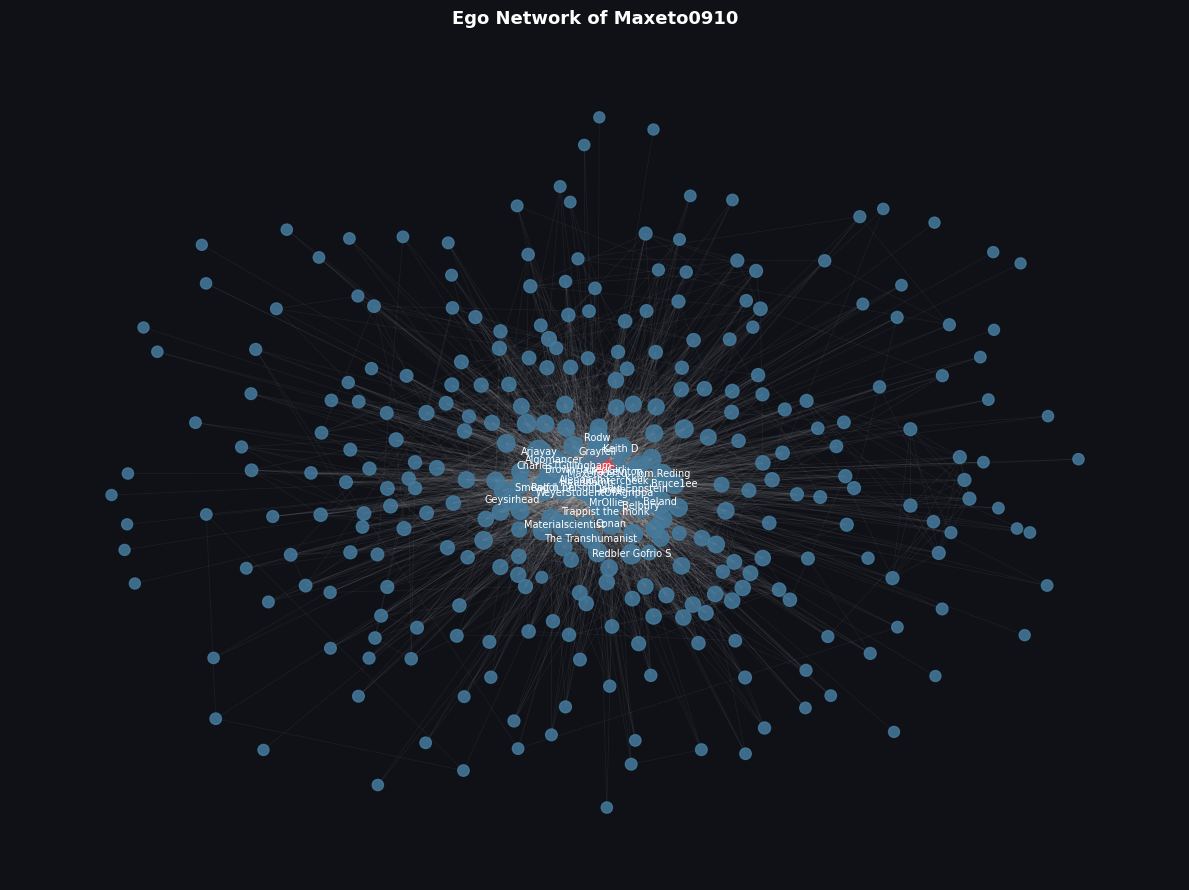

saved: ego_network.png


In [20]:
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor']   = '#0f1117'

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor('#0f1117')
ax.set_title(f'Ego Network of {center}', color='white', fontsize=13,
             fontweight='bold', pad=15)
ax.axis('off')

pos = nx.spring_layout(ego, seed=42, k=0.7)

node_colors = []
node_sizes  = []
for n in ego.nodes():
    if n == center:
        node_colors.append('#e63946')
        node_sizes.append(700)
    else:
        node_colors.append('#457b9d')
        node_sizes.append(60 + G_main.degree(n) * 2.5)

edge_widths = [ego[u][v].get('weight', 1) * 0.3 for u, v in ego.edges()]

nx.draw_networkx_edges(ego, pos, ax=ax, width=edge_widths,
                       edge_color='white', alpha=0.05)
nx.draw_networkx_nodes(ego, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85)

labels = {n: n for n in ego.nodes() if n == center or G_main.degree(n) > 50}
nx.draw_networkx_labels(ego, pos, labels=labels, ax=ax,
                        font_size=7, font_color='white')

plt.tight_layout()
plt.savefig('ego_network.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("saved: ego_network.png")

## 3.4 Community Detection

We apply the Louvain algorithm to detect communities in the network.
The algorithm optimizes modularity Q — a measure of how strongly the
network divides into distinct groups, with high internal connectivity
and lower between-group connectivity.

In [21]:
from community import community_louvain

partition = community_louvain.best_partition(G_main, weight='weight')

n_comms = len(set(partition.values()))
mod     = community_louvain.modularity(partition, G_main)

print(f"communities found : {n_comms}")
print(f"modularity Q      : {mod:.4f}")
print(f"  (Q > 0.30 = meaningful structure)")

print()
sizes = Counter(partition.values())
print("community sizes:")
for cid, s in sorted(sizes.items(), key=lambda x: -x[1]):
    bar = '#' * (s // 3)
    print(f"  community {cid}: {s:>3} editors  {bar}")

communities found : 7
modularity Q      : 0.2136
  (Q > 0.30 = meaningful structure)

community sizes:
  community 0: 115 editors  ######################################
  community 1:  98 editors  ################################
  community 3:  79 editors  ##########################
  community 2:  75 editors  #########################
  community 6:  60 editors  ####################
  community 5:  32 editors  ##########
  community 4:   8 editors  ##


In [22]:
df['community'] = df['editor'].map(partition)

print("most central editor in each community (by betweenness):")
print(f"\n  {'comm':<5} {'leader':<25} {'btw':>8} {'deg':>8} {'size':>5}")
print(f"  {'-'*5} {'-'*25} {'-'*8} {'-'*8} {'-'*5}")

for cid in sorted(sizes.keys()):
    members = df[df['community'] == cid]
    if len(members) == 0:
        continue
    leader = members.nlargest(1, 'betweenness').iloc[0]
    print(f"  {cid:<5} {leader['editor']:<25} "
          f"{leader['betweenness']:>8.4f} "
          f"{leader['degree']:>8.4f} "
          f"{sizes[cid]:>5}")

most central editor in each community (by betweenness):

  comm  leader                         btw      deg  size
  ----- ------------------------- -------- -------- -----
  0     Headbomb                    0.1039   0.4871   115
  1     Jarble                      0.1212   0.5300    98
  2     Maxeto0910                  0.2402   0.6781    75
  3     MrOllie                     0.0811   0.4399    79
  4     114.10.8.178                0.0018   0.0451     8
  5     Ira Leviton                 0.0309   0.2146    32
  6     Keith D                     0.0169   0.1609    60


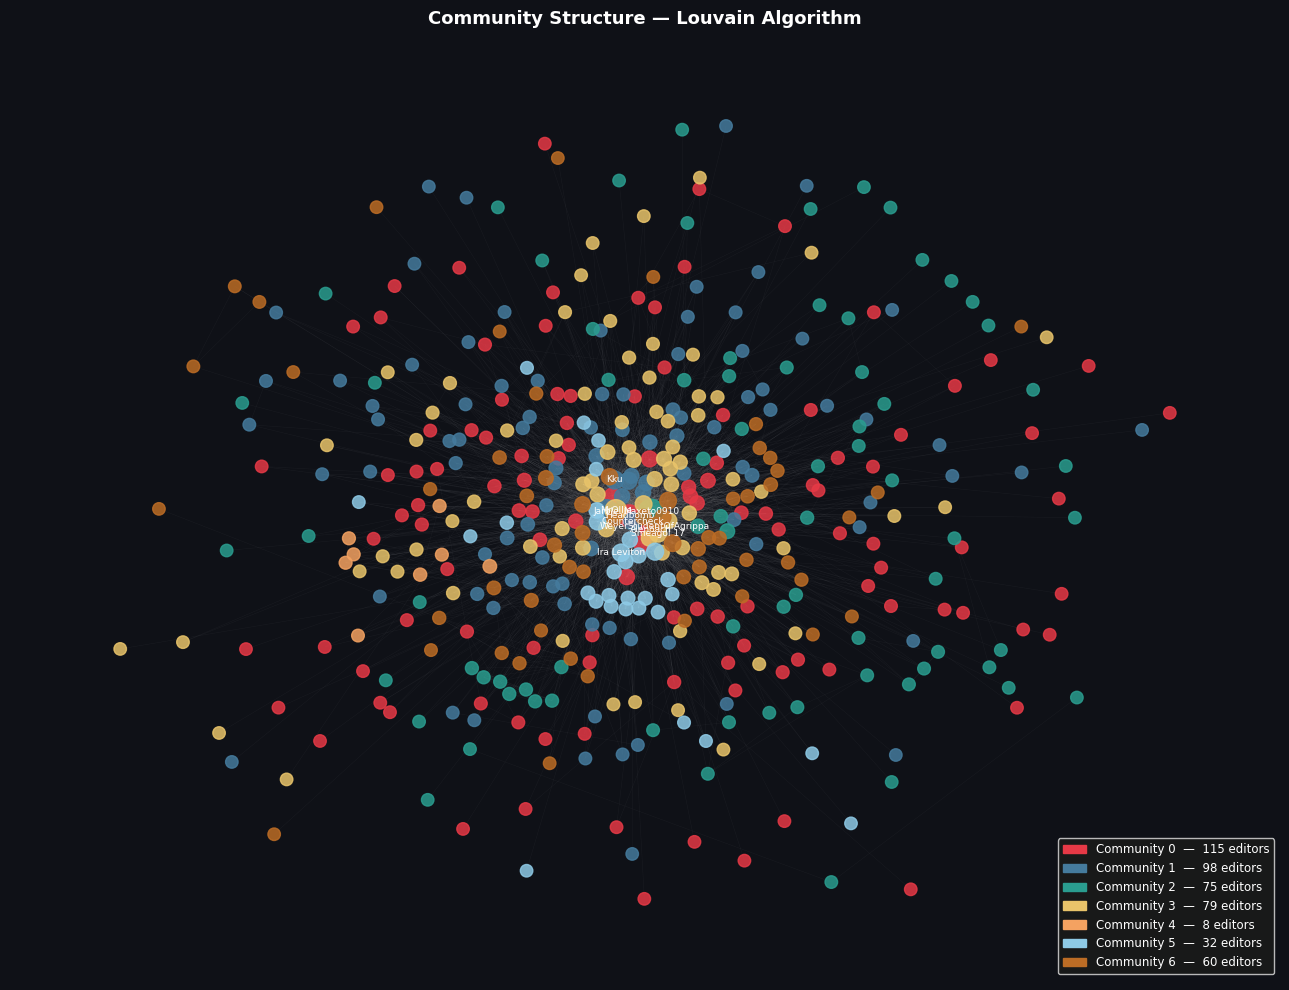

saved: communities.png


In [23]:
import matplotlib.patches as mpatches

PALETTE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a',
           '#f4a261', '#8ecae6', '#bc6c25']

pos = nx.spring_layout(G_main, seed=42, k=0.4)

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.set_title('Community Structure — Louvain Algorithm',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.axis('off')

for cid in sorted(sizes.keys()):
    nodes = [n for n, c in partition.items() if c == cid]
    color = PALETTE[cid % len(PALETTE)]
    node_sizes = [80 + deg_cent[n] * 350 for n in nodes]
    nx.draw_networkx_nodes(G_main, pos, nodelist=nodes,
                           node_color=color, node_size=node_sizes,
                           ax=ax, alpha=0.85)

nx.draw_networkx_edges(G_main, pos, ax=ax,
                       edge_color='white', alpha=0.04, width=0.4)

labels = {n: n for n in G_main.nodes() if deg_cent[n] > 0.20}
nx.draw_networkx_labels(G_main, pos, labels=labels,
                        ax=ax, font_size=6.5, font_color='white')

patches = [
    mpatches.Patch(color=PALETTE[c % len(PALETTE)],
                   label=f'Community {c}  —  {sizes[c]} editors')
    for c in sorted(sizes.keys())
]
ax.legend(handles=patches, loc='lower right',
          facecolor='#1a1a1a', labelcolor='white',
          fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.savefig('communities.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("saved: communities.png")

## 3.5 Small-World Test

The small-world property describes networks with high local clustering
and short average path lengths. We test this using the Watts–Strogatz
framework: comparing the real network's clustering and path length to
those of an equivalent random graph. Sigma > 1 indicates small-world.

In [25]:
import random

C_real = nx.average_clustering(G_main, weight='weight')
L_real = nx.average_shortest_path_length(G_main)

n = G_main.number_of_nodes()
m = G_main.number_of_edges()
k = int(2 * m / n)

random.seed(42)
R = nx.watts_strogatz_graph(n, k, 0.1, seed=42)

C_rand = nx.average_clustering(R)
L_rand = nx.average_shortest_path_length(R)

sigma = (C_real / C_rand) / (L_real / L_rand)

print("small-world test:")
print(f"\n  {'metric':<25} {'real':>10} {'random':>10}")
print(f"  {'-'*25} {'-'*10} {'-'*10}")
print(f"  {'clustering coef':<25} {C_real:>10.4f} {C_rand:>10.4f}")
print(f"  {'avg path length':<25} {L_real:>10.4f} {L_rand:>10.4f}")
print()
print(f"  sigma = {sigma:.4f}")
print()

if sigma > 1:
    print("  result: small-world structure DETECTED")
else:
    print("  result: NO small-world structure")
    print(f"          clustering is {C_rand/C_real:.1f}x lower than random")

small-world test:

  metric                          real     random
  ------------------------- ---------- ----------
  clustering coef               0.0752     0.5119
  avg path length               2.2764     3.2863

  sigma = 0.2121

  result: NO small-world structure
          clustering is 6.8x lower than random


## 3.6 Network Robustness Test

We simulate the removal of high-centrality "hub" editors from the network
and observe how the network fragments. This reveals the structural
vulnerability that comes with hub dependency.

In [26]:
def network_stats(G):
    if G.number_of_nodes() == 0:
        return {'nodes': 0, 'edges': 0, 'components': 0, 'largest_cc': 0}
    return {
        'nodes'      : G.number_of_nodes(),
        'edges'      : G.number_of_edges(),
        'components' : nx.number_connected_components(G),
        'largest_cc' : max(len(c) for c in nx.connected_components(G)),
    }


hub_list = [e for e, _ in top_btw[:20]]

results = []
G_test  = G_main.copy()

print("removing hub editors one by one:")
print(f"\n  {'#':<3} {'editor':<25} {'comp':>5} {'largest':>8} {'lost':>5}")
print(f"  {'-'*3} {'-'*25} {'-'*5} {'-'*8} {'-'*5}")

baseline_size = G_main.number_of_nodes()

for i, ed in enumerate(hub_list):
    if ed not in G_test.nodes():
        continue
    G_test.remove_node(ed)
    s = network_stats(G_test)
    s['removed'] = ed
    s['step'] = i + 1
    s['lost'] = baseline_size - s['largest_cc']
    results.append(s)
    
    print(f"  {i+1:<3} {ed:<25} "
          f"{s['components']:>5} "
          f"{s['largest_cc']:>8} "
          f"{s['lost']:>5}")

removing hub editors one by one:

  #   editor                     comp  largest  lost
  --- ------------------------- ----- -------- -----
  1   Maxeto0910                   19      444    23
  2   Jarble                       23      439    28
  3   Headbomb                     31      430    37
  4   Alenoach                     34      426    41
  5   MrOllie                      44      414    53
  6   Kku                          52      398    69
  7   Ira Leviton                  58      390    77
  8   Arjayay                      63      384    83
  9   Rodw                         68      377    90
  10  Countercheck                 71      373    94
  11  Onel5969                     75      368    99
  12  BrownHairedGirl              79      363   104
  13  Keith D                      82      359   108
  14  Materialscientist            83      357   110
  15  Grayfell                     84      354   113
  16  Smeagol 17                   85      351   116
  17  Nbro  

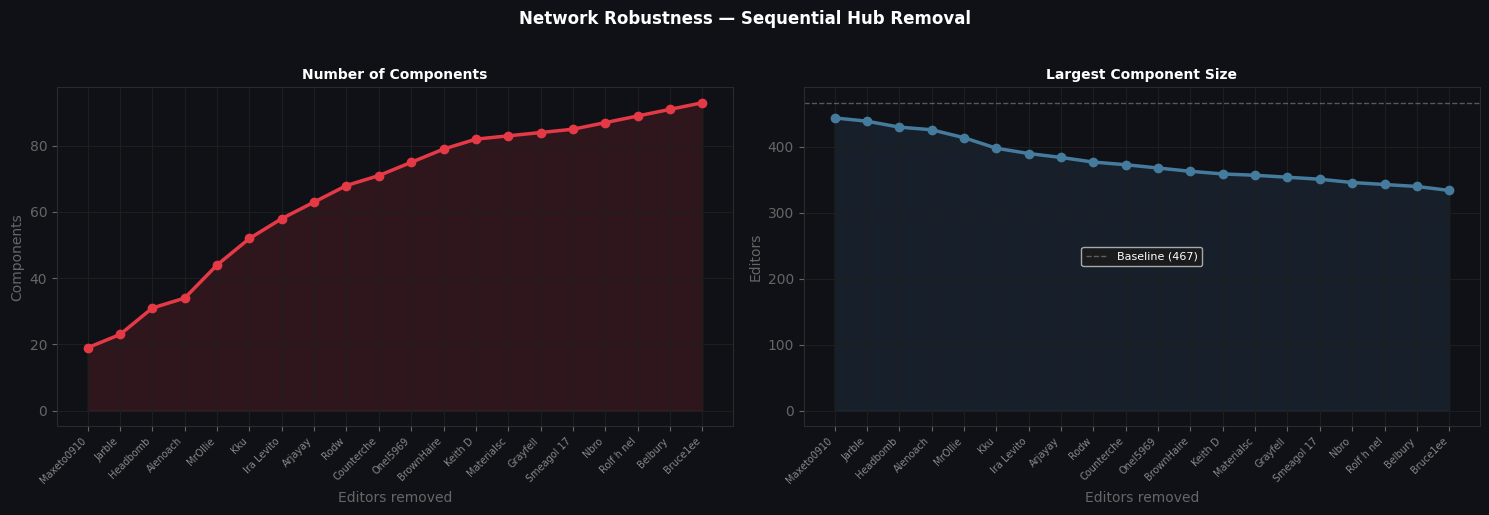

saved: robustness_test.png


In [27]:
df_rob = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Network Robustness — Sequential Hub Removal',
             color='white', fontsize=12, fontweight='bold', y=1.02)

ax1 = axes[0]
ax1.set_facecolor('#0f1117')
ax1.plot(df_rob['step'], df_rob['components'],
         color='#e63946', linewidth=2.5, marker='o', markersize=6)
ax1.fill_between(df_rob['step'], df_rob['components'],
                 alpha=0.15, color='#e63946')
ax1.set_title('Number of Components', color='white',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Editors removed', color='#666')
ax1.set_ylabel('Components', color='#666')
ax1.tick_params(colors='#666')
for s in ax1.spines.values(): s.set_color('#2a2a2a')
ax1.grid(color='#1e1e1e', linewidth=0.8)

ax2 = axes[1]
ax2.set_facecolor('#0f1117')
ax2.plot(df_rob['step'], df_rob['largest_cc'],
         color='#457b9d', linewidth=2.5, marker='o', markersize=6)
ax2.fill_between(df_rob['step'], df_rob['largest_cc'],
                 alpha=0.15, color='#457b9d')
ax2.axhline(y=baseline_size, color='white', linestyle='--',
            alpha=0.3, linewidth=1, label=f'Baseline ({baseline_size})')
ax2.set_title('Largest Component Size', color='white',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Editors removed', color='#666')
ax2.set_ylabel('Editors', color='#666')
ax2.tick_params(colors='#666')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
for s in ax2.spines.values(): s.set_color('#2a2a2a')
ax2.grid(color='#1e1e1e', linewidth=0.8)

for ax in axes:
    ax.set_xticks(df_rob['step'])
    ax.set_xticklabels([r['removed'][:10] for r in results],
                       rotation=45, ha='right', fontsize=7, color='#888')

plt.tight_layout()
plt.savefig('robustness_test.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: robustness_test.png")

# Phase 4 — Temporal Analysis

We track how the network evolved between 2018 and 2025 by constructing
cumulative annual snapshots. This phase reveals the structural impact of
the November 2022 release of ChatGPT and shows how new editor cohorts
integrate into the existing community.

## 4.1 Building Annual Snapshots

In [28]:
yearly_data = {}

for yr in range(2018, 2026):
    art_eds = defaultdict(set)
    for article, revs in clean_data.items():
        for r in revs:
            if r['year'] <= yr:
                art_eds[article].add(r['user'])
    yearly_data[yr] = art_eds
    
    total_eds = len(set(u for s in art_eds.values() for u in s))
    print(f"  {yr}: {len(art_eds)} articles, {total_eds} editors (cumulative)")

  2018: 92 articles, 986 editors (cumulative)
  2019: 109 articles, 1839 editors (cumulative)
  2020: 126 articles, 2623 editors (cumulative)
  2021: 136 articles, 3136 editors (cumulative)
  2022: 141 articles, 3671 editors (cumulative)
  2023: 150 articles, 4435 editors (cumulative)
  2024: 164 articles, 5182 editors (cumulative)
  2025: 212 articles, 6462 editors (cumulative)


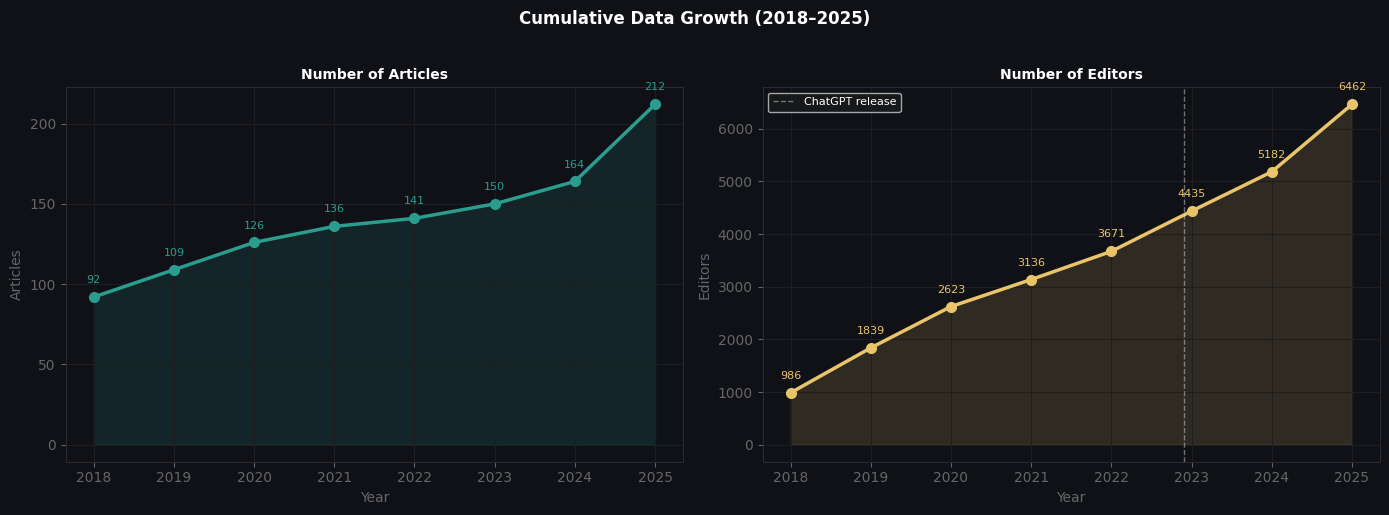

saved: cumulative_growth.png


In [29]:
years = sorted(yearly_data.keys())
art_counts = [len(yearly_data[y]) for y in years]
ed_counts  = [len(set(u for s in yearly_data[y].values() for u in s)) for y in years]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Cumulative Data Growth (2018–2025)',
             color='white', fontsize=12, fontweight='bold', y=1.02)

ax1 = axes[0]
ax1.set_facecolor('#0f1117')
ax1.plot(years, art_counts, color='#2a9d8f', linewidth=2.5,
         marker='o', markersize=7)
ax1.fill_between(years, art_counts, alpha=0.15, color='#2a9d8f')
ax1.set_title('Number of Articles', color='white',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Year', color='#666')
ax1.set_ylabel('Articles', color='#666')
ax1.tick_params(colors='#666')

for x, y in zip(years, art_counts):
    ax1.annotate(str(y), xy=(x, y), xytext=(0, 10),
                 textcoords='offset points', ha='center',
                 fontsize=8, color='#2a9d8f')

for s in ax1.spines.values(): s.set_color('#2a2a2a')
ax1.grid(color='#1e1e1e', linewidth=0.8)

ax2 = axes[1]
ax2.set_facecolor('#0f1117')
ax2.plot(years, ed_counts, color='#e9c46a', linewidth=2.5,
         marker='o', markersize=7)
ax2.fill_between(years, ed_counts, alpha=0.15, color='#e9c46a')
ax2.axvline(x=2022.9, color='white', linestyle='--',
            alpha=0.4, linewidth=1, label='ChatGPT release')
ax2.set_title('Number of Editors', color='white',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Year', color='#666')
ax2.set_ylabel('Editors', color='#666')
ax2.tick_params(colors='#666')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)

for x, y in zip(years, ed_counts):
    ax2.annotate(str(y), xy=(x, y), xytext=(0, 10),
                 textcoords='offset points', ha='center',
                 fontsize=8, color='#e9c46a')

for s in ax2.spines.values(): s.set_color('#2a2a2a')
ax2.grid(color='#1e1e1e', linewidth=0.8)

plt.tight_layout()
plt.savefig('cumulative_growth.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: cumulative_growth.png")

In [30]:
yearly_nets = {}

for yr, art_eds in yearly_data.items():
    G_y = nx.Graph()
    
    for article, eds in art_eds.items():
        ed_list = list(eds)
        if len(ed_list) > 300:
            continue
        for u, v in itertools.combinations(ed_list, 2):
            if G_y.has_edge(u, v):
                G_y[u][v]['weight'] += 1
            else:
                G_y.add_edge(u, v, weight=1)
    
    weak = [(u, v) for u, v, d in G_y.edges(data=True) if d['weight'] < 2]
    G_y.remove_edges_from(weak)
    G_y.remove_nodes_from(list(nx.isolates(G_y)))
    
    if G_y.number_of_nodes() > 0:
        largest = max(nx.connected_components(G_y), key=len)
        G_y = G_y.subgraph(largest).copy()
    
    yearly_nets[yr] = G_y
    print(f"  {yr}: {G_y.number_of_nodes():>3} nodes, {G_y.number_of_edges():>5} edges")

  2018:  26 nodes,    29 edges
  2019:  71 nodes,   189 edges
  2020: 128 nodes,   631 edges
  2021: 180 nodes,  1103 edges
  2022: 218 nodes,  1447 edges
  2023: 278 nodes,  1997 edges
  2024: 344 nodes,  3091 edges
  2025: 467 nodes,  3705 edges


In [31]:
metrics = []

for yr, G_y in yearly_nets.items():
    if G_y.number_of_nodes() < 2:
        continue
    
    row = {
        'year'      : yr,
        'nodes'     : G_y.number_of_nodes(),
        'edges'     : G_y.number_of_edges(),
        'density'   : nx.density(G_y),
        'avg_degree': sum(d for _, d in G_y.degree()) / G_y.number_of_nodes(),
        'clustering': nx.average_clustering(G_y, weight='weight'),
    }
    
    if nx.is_connected(G_y):
        row['avg_path'] = nx.average_shortest_path_length(G_y)
    else:
        row['avg_path'] = None
    
    metrics.append(row)

df_yearly = pd.DataFrame(metrics)

print("yearly network metrics:")
print(f"\n  {'year':>4} {'nodes':>5} {'edges':>5} {'density':>8} "
      f"{'avg_deg':>8} {'cluster':>8} {'path':>5}")
print(f"  {'-'*4} {'-'*5} {'-'*5} {'-'*8} {'-'*8} {'-'*8} {'-'*5}")

for _, r in df_yearly.iterrows():
    p = f"{r['avg_path']:.2f}" if r['avg_path'] else " - "
    print(f"  {int(r['year']):>4} {int(r['nodes']):>5} {int(r['edges']):>5} "
          f"{r['density']:>8.4f} {r['avg_degree']:>8.2f} "
          f"{r['clustering']:>8.4f} {p:>5}")

yearly network metrics:

  year nodes edges  density  avg_deg  cluster  path
  ---- ----- ----- -------- -------- -------- -----
  2018    26    29   0.0892     2.23   0.1497  2.36
  2019    71   189   0.0761     5.32   0.1682  2.21
  2020   128   631   0.0776     9.86   0.1438  2.29
  2021   180  1103   0.0685    12.26   0.1372  2.19
  2022   218  1447   0.0612    13.28   0.1361  2.18
  2023   278  1997   0.0519    14.37   0.1210  2.22
  2024   344  3091   0.0524    17.97   0.0863  2.22
  2025   467  3705   0.0340    15.87   0.0752  2.28


## 4.2 Visualizing Network Evolution

We visualize how each network metric changed year by year. The dashed
vertical line marks November 2022 — the public release of ChatGPT —
to highlight the structural shift that followed.

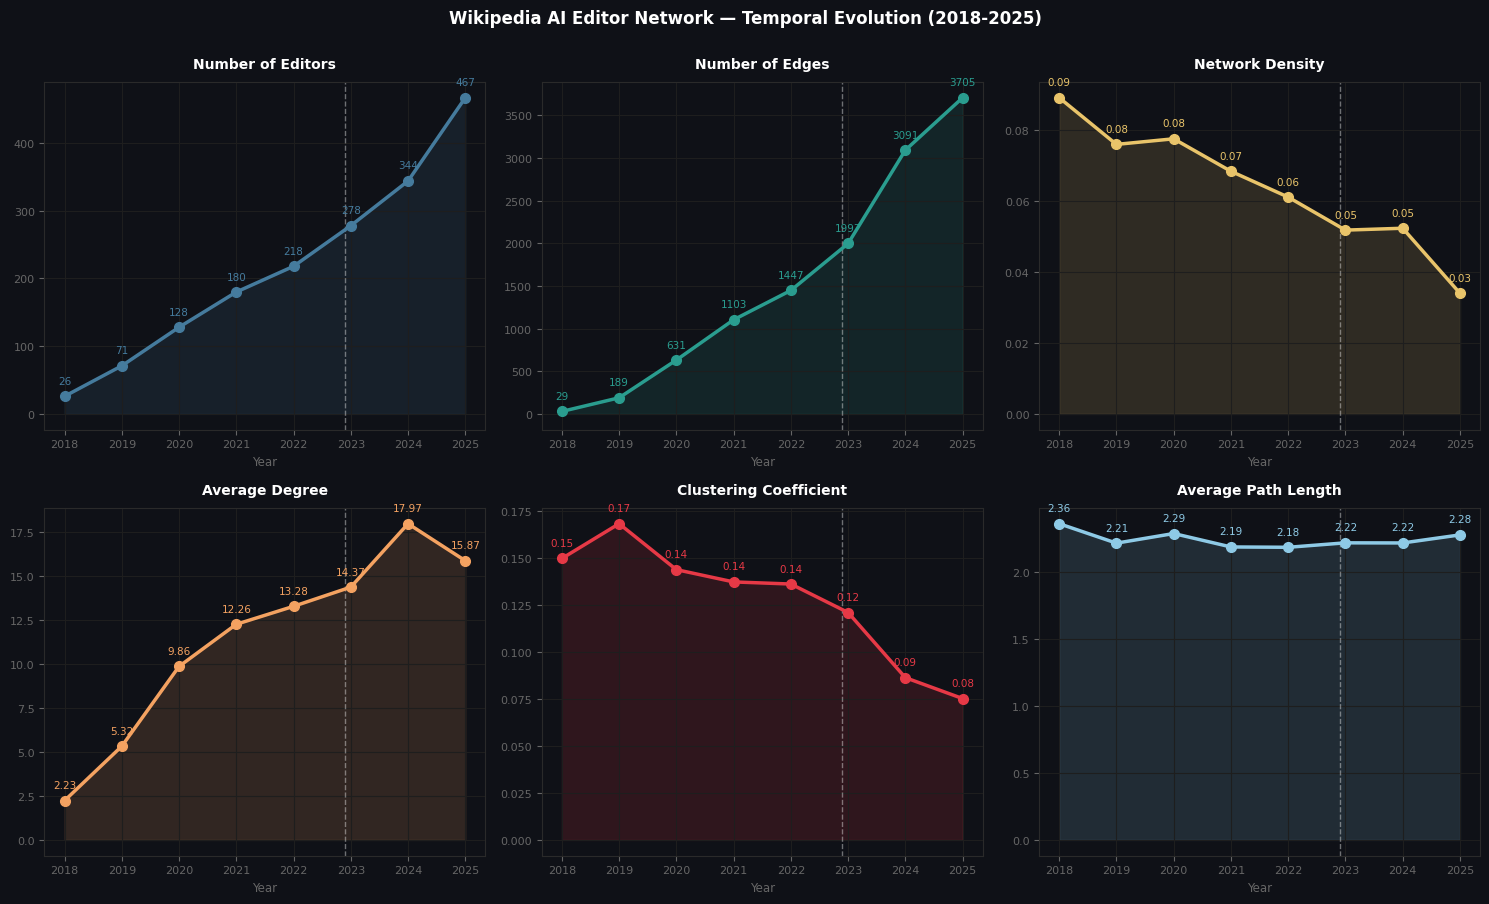

saved: temporal_evolution.png


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Wikipedia AI Editor Network — Temporal Evolution (2018-2025)',
             color='white', fontsize=12, fontweight='bold', y=1.00)

panels = [
    ('nodes',      'Number of Editors',      '#457b9d'),
    ('edges',      'Number of Edges',        '#2a9d8f'),
    ('density',    'Network Density',        '#e9c46a'),
    ('avg_degree', 'Average Degree',         '#f4a261'),
    ('clustering', 'Clustering Coefficient', '#e63946'),
    ('avg_path',   'Average Path Length',    '#8ecae6'),
]

for ax, (col, label, color) in zip(axes.flat, panels):
    ax.set_facecolor('#0f1117')
    
    data = df_yearly.dropna(subset=[col]) if col == 'avg_path' else df_yearly
    
    ax.plot(data['year'], data[col], color=color,
            linewidth=2.5, marker='o', markersize=7, zorder=3)
    ax.fill_between(data['year'], data[col], alpha=0.15, color=color)
    
    ax.axvline(x=2022.9, color='white', linestyle='--',
               alpha=0.4, linewidth=1)
    
    for _, row in data.iterrows():
        val = row[col]
        if col in ('density', 'clustering', 'avg_path', 'avg_degree'):
            text = f"{val:.2f}"
        else:
            text = f"{int(val)}"
        ax.annotate(text, xy=(row['year'], val),
                    xytext=(0, 9), textcoords='offset points',
                    ha='center', fontsize=7.5, color=color)
    
    ax.set_title(label, color='white', fontsize=10,
                 fontweight='bold', pad=10)
    ax.set_xlabel('Year', color='#666', fontsize=8.5)
    ax.set_xticks(data['year'])
    ax.tick_params(colors='#666', labelsize=8)
    for s in ax.spines.values(): s.set_color('#2a2a2a')
    ax.grid(color='#1e1e1e', linewidth=0.8)

plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: temporal_evolution.png")

## 4.3 Cohort Analysis

We track each year's new editors and their integration into the network.
Editors who joined in 2018 had years to embed themselves into the
community; those who joined in 2024-2025 are still establishing connections.
This analysis quantifies the integration gap between cohorts.

In [33]:
first_seen = {}

for yr in sorted(yearly_nets.keys()):
    G_y = yearly_nets[yr]
    for node in G_y.nodes():
        if node not in first_seen:
            first_seen[node] = yr


cohorts = []
G_final = yearly_nets[2025]

for yr in sorted(yearly_nets.keys()):
    new_eds = [n for n, fy in first_seen.items() if fy == yr]
    survived = [n for n in new_eds if n in G_final.nodes()]
    
    if not survived:
        continue
    
    degs = [G_final.degree(n) for n in survived]
    
    cohorts.append({
        'cohort_year'   : yr,
        'new_editors'   : len(new_eds),
        'survived'      : len(survived),
        'survival_rate' : len(survived) / len(new_eds) * 100,
        'avg_degree'    : np.mean(degs),
    })

df_coh = pd.DataFrame(cohorts)

print("editor cohort analysis — how each year's newcomers fared in 2025:")
print(f"\n  {'cohort':>7} {'new':>5} {'survived':>10} "
      f"{'survival %':>12} {'avg degree':>12}")
print(f"  {'-'*7} {'-'*5} {'-'*10} {'-'*12} {'-'*12}")

for _, r in df_coh.iterrows():
    print(f"  {int(r['cohort_year']):>7} "
          f"{int(r['new_editors']):>5} "
          f"{int(r['survived']):>10} "
          f"{r['survival_rate']:>11.1f}% "
          f"{r['avg_degree']:>12.2f}")

editor cohort analysis — how each year's newcomers fared in 2025:

   cohort   new   survived   survival %   avg degree
  ------- ----- ---------- ------------ ------------
     2018    26         24        92.3%        46.12
     2019    45         37        82.2%        28.70
     2020    57         41        71.9%        22.00
     2021    52         37        71.2%        22.84
     2022    53         44        83.0%        17.00
     2023    80         73        91.2%        17.33
     2024    80         68        85.0%         9.68
     2025   143        143       100.0%         5.76


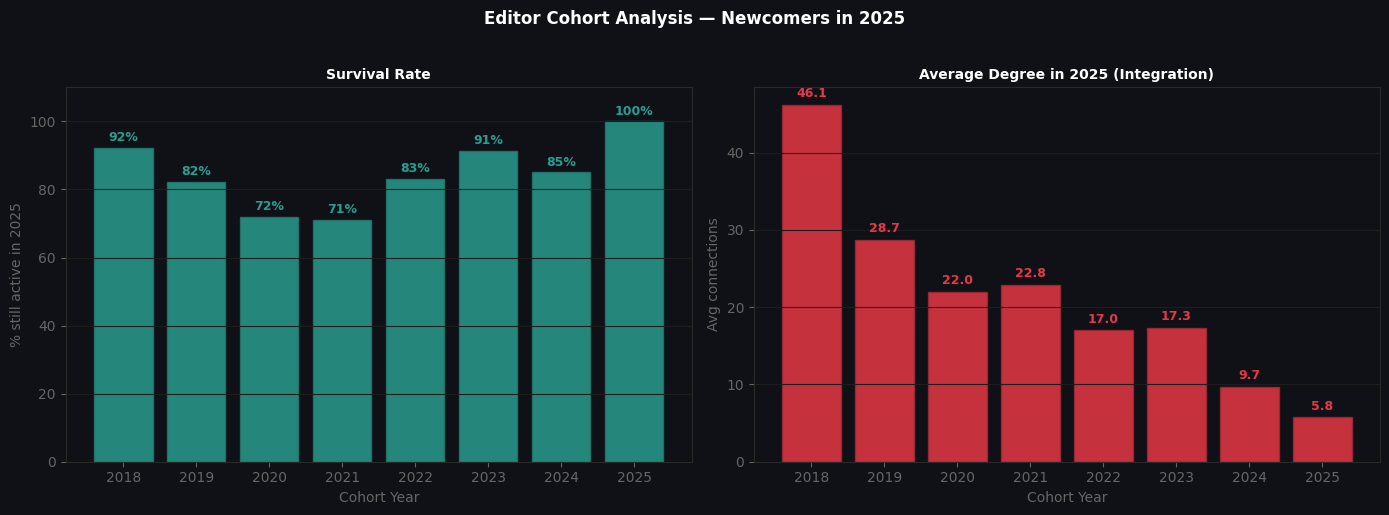

saved: cohort_analysis.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Editor Cohort Analysis — Newcomers in 2025',
             color='white', fontsize=12, fontweight='bold', y=1.02)

ax1 = axes[0]
ax1.set_facecolor('#0f1117')
bars1 = ax1.bar(df_coh['cohort_year'], df_coh['survival_rate'],
                color='#2a9d8f', alpha=0.85, edgecolor='#1f7a6c')
ax1.set_title('Survival Rate', color='white',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Cohort Year', color='#666')
ax1.set_ylabel('% still active in 2025', color='#666')
ax1.set_ylim(0, 110)
ax1.tick_params(colors='#666')
for s in ax1.spines.values(): s.set_color('#2a2a2a')
ax1.grid(axis='y', color='#1e1e1e', linewidth=0.8)

for bar, val in zip(bars1, df_coh['survival_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 2,
             f"{val:.0f}%", ha='center', color='#2a9d8f',
             fontsize=9, fontweight='bold')

ax2 = axes[1]
ax2.set_facecolor('#0f1117')
bars2 = ax2.bar(df_coh['cohort_year'], df_coh['avg_degree'],
                color='#e63946', alpha=0.85, edgecolor='#a02834')
ax2.set_title('Average Degree in 2025 (Integration)', color='white',
              fontsize=10, fontweight='bold')
ax2.set_xlabel('Cohort Year', color='#666')
ax2.set_ylabel('Avg connections', color='#666')
ax2.tick_params(colors='#666')
for s in ax2.spines.values(): s.set_color('#2a2a2a')
ax2.grid(axis='y', color='#1e1e1e', linewidth=0.8)

for bar, val in zip(bars2, df_coh['avg_degree']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f"{val:.1f}", ha='center', color='#e63946',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('cohort_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: cohort_analysis.png")

# Phase 5 — Final Visualizations

We now produce the final report-ready visualizations: a comparison of
top editors across all four centrality metrics, the degree distribution
with power law fit, an interactive network visualization, and a
summary metrics table.

## 5.1 Top 10 Centrality Comparison

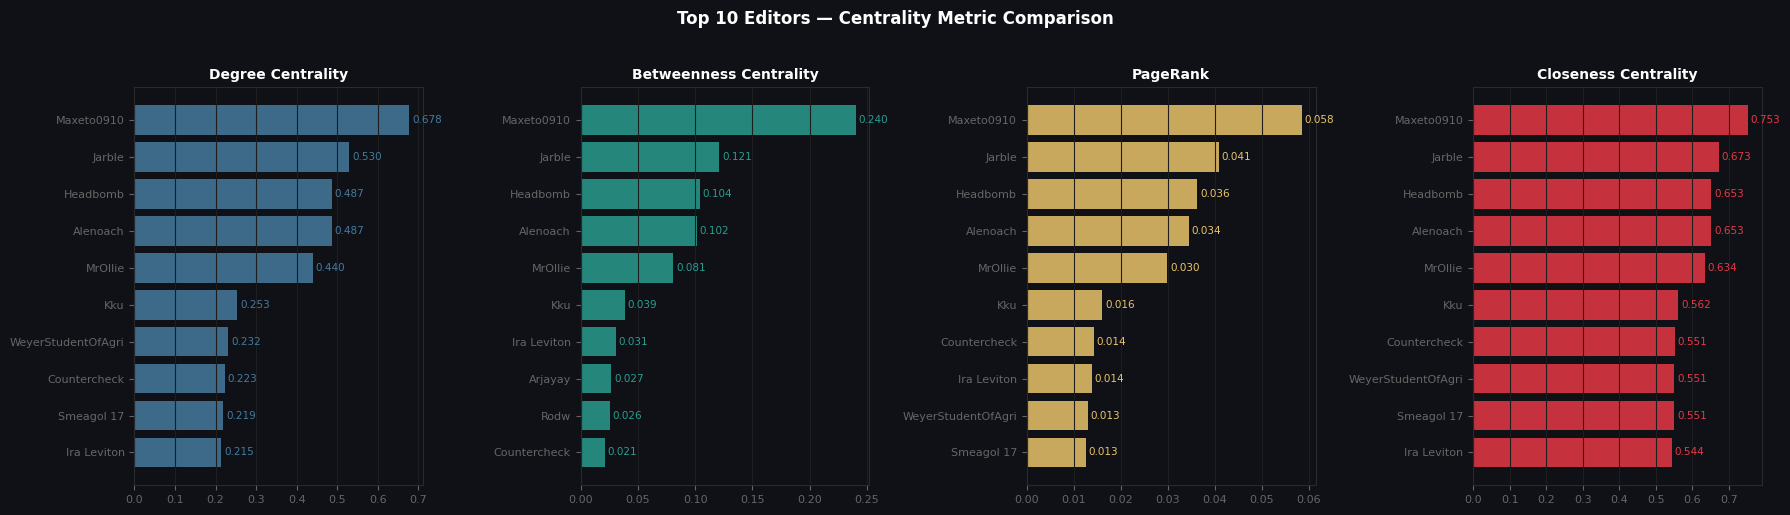

saved: top10_centrality.png


In [35]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Top 10 Editors — Centrality Metric Comparison',
             color='white', fontsize=12, fontweight='bold', y=1.02)

panels = [
    (deg_cent, 'Degree Centrality',      '#457b9d'),
    (btw,      'Betweenness Centrality', '#2a9d8f'),
    (pr,       'PageRank',               '#e9c46a'),
    (cls,      'Closeness Centrality',   '#e63946'),
]

for ax, (metric, label, color) in zip(axes, panels):
    ax.set_facecolor('#0f1117')
    
    top10 = sorted(metric.items(), key=lambda x: x[1], reverse=True)[:10]
    names = [t[0][:18] for t in top10]
    vals  = [t[1] for t in top10]
    
    bars = ax.barh(range(len(names)), vals, color=color, alpha=0.85)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, color='white', fontsize=8.5)
    ax.set_title(label, color='white', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.tick_params(colors='#666', labelsize=8)
    for s in ax.spines.values(): s.set_color('#2a2a2a')
    ax.grid(axis='x', color='#1e1e1e', linewidth=0.8)
    
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', color=color, fontsize=7.5)

plt.tight_layout()
plt.savefig('top10_centrality.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: top10_centrality.png")

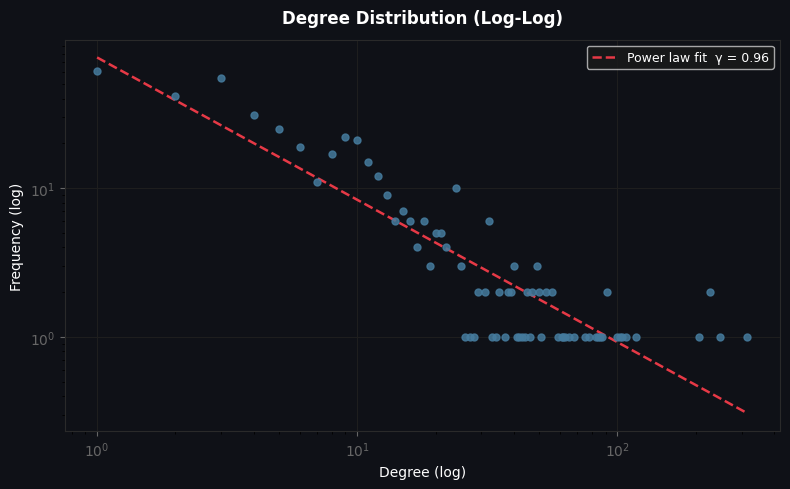

saved: degree_distribution.png

gamma exponent: 0.9567


In [36]:
all_degs = [d for _, d in G_main.degree()]
deg_count = Counter(all_degs)

xs = sorted(deg_count.keys())
ys = [deg_count[x] for x in xs]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

ax.scatter(xs, ys, color='#457b9d', s=25, alpha=0.85, zorder=3)
ax.set_xscale('log')
ax.set_yscale('log')

log_x = np.log(xs)
log_y = np.log(ys)
coeffs = np.polyfit(log_x, log_y, 1)
fit_y = np.exp(np.polyval(coeffs, log_x))

ax.plot(xs, fit_y, color='#e63946', linewidth=1.8,
        linestyle='--', label=f'Power law fit  γ = {abs(coeffs[0]):.2f}')

ax.set_xlabel('Degree (log)', color='white', fontsize=10)
ax.set_ylabel('Frequency (log)', color='white', fontsize=10)
ax.set_title('Degree Distribution (Log-Log)', color='white',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax.tick_params(colors='#666')
for s in ax.spines.values(): s.set_color('#2a2a2a')
ax.grid(color='#1e1e1e', linewidth=0.8)

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: degree_distribution.png")
print(f"\ngamma exponent: {abs(coeffs[0]):.4f}")

In [39]:
from pyvis.network import Network

net = Network(height='700px', width='100%',
              bgcolor='#0f1117', font_color='white',
              notebook=False)

net.barnes_hut(gravity=-8000, central_gravity=0.3,
               spring_length=100, spring_strength=0.05)

PALETTE = ['#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261','#8ecae6','#bc6c25']

for node in G_main.nodes():
    comm = partition[node]
    color = PALETTE[comm % len(PALETTE)]
    size = 10 + deg_cent[node] * 60
    
    title = (f"<b>{node}</b><br>"
             f"Community: {comm}<br>"
             f"Degree: {G_main.degree(node)}<br>"
             f"Betweenness: {btw[node]:.4f}<br>"
             f"PageRank: {pr[node]:.4f}")
    
    net.add_node(node, label=node, color=color, size=size, title=title)


for u, v, data in G_main.edges(data=True):
    weight = data.get('weight', 1)
    net.add_edge(u, v, value=weight, color='rgba(255,255,255,0.1)')


net.set_options("""
{
  "nodes": {"font": {"size": 11, "color": "white"}},
  "edges": {"smooth": {"type": "continuous"}},
  "interaction": {"hover": true, "tooltipDelay": 100},
  "physics": {"stabilization": {"iterations": 200}}
}
""")

net.save_graph('network_interactive.html')
print("saved: network_interactive.html")
print("open in browser to explore")

saved: network_interactive.html
open in browser to explore


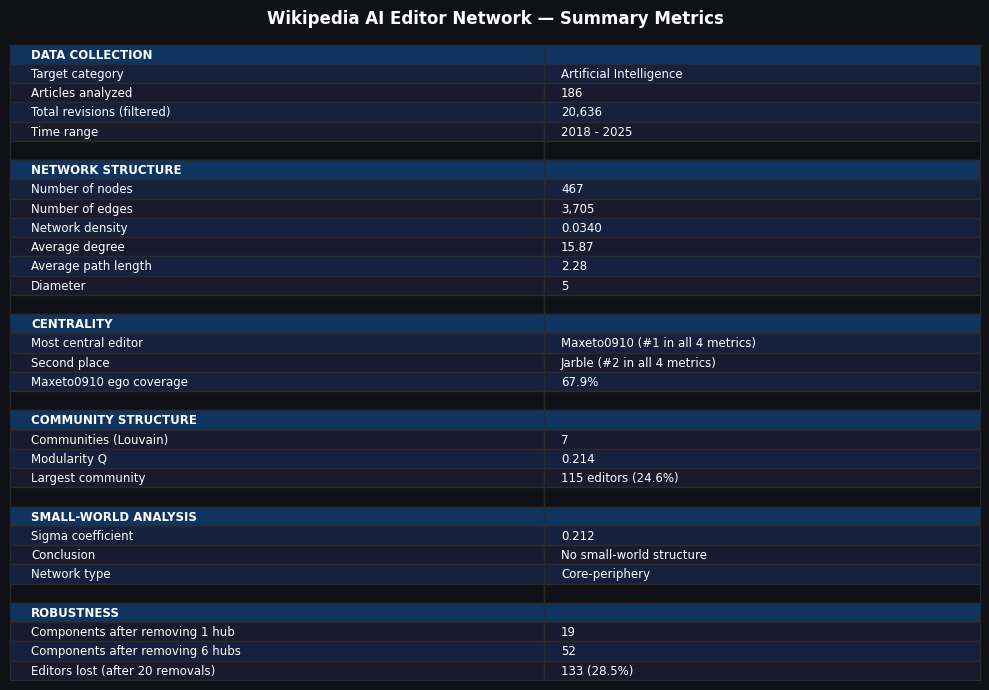

saved: summary_metrics.png


In [40]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.axis('off')
ax.set_title('Wikipedia AI Editor Network — Summary Metrics',
             color='white', fontsize=12, fontweight='bold', pad=20)

rows = [
    ['DATA COLLECTION', ''],
    ['Target category', 'Artificial Intelligence'],
    ['Articles analyzed', '186'],
    ['Total revisions (filtered)', '20,636'],
    ['Time range', '2018 - 2025'],
    ['', ''],
    ['NETWORK STRUCTURE', ''],
    ['Number of nodes', '467'],
    ['Number of edges', '3,705'],
    ['Network density', '0.0340'],
    ['Average degree', '15.87'],
    ['Average path length', '2.28'],
    ['Diameter', '5'],
    ['', ''],
    ['CENTRALITY', ''],
    ['Most central editor', 'Maxeto0910 (#1 in all 4 metrics)'],
    ['Second place', 'Jarble (#2 in all 4 metrics)'],
    ['Maxeto0910 ego coverage', '67.9%'],
    ['', ''],
    ['COMMUNITY STRUCTURE', ''],
    ['Communities (Louvain)', '7'],
    ['Modularity Q', '0.214'],
    ['Largest community', '115 editors (24.6%)'],
    ['', ''],
    ['SMALL-WORLD ANALYSIS', ''],
    ['Sigma coefficient', '0.212'],
    ['Conclusion', 'No small-world structure'],
    ['Network type', 'Core-periphery'],
    ['', ''],
    ['ROBUSTNESS', ''],
    ['Components after removing 1 hub', '19'],
    ['Components after removing 6 hubs', '52'],
    ['Editors lost (after 20 removals)', '133 (28.5%)'],
]

table = ax.table(cellText=rows, cellLoc='left',
                 loc='center', colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(8.5)

section_headers = ['DATA COLLECTION', 'NETWORK STRUCTURE', 'CENTRALITY',
                   'COMMUNITY STRUCTURE', 'SMALL-WORLD ANALYSIS', 'ROBUSTNESS']

for (r, c), cellobj in table.get_celld().items():
    cellobj.set_edgecolor('#2a2a2a')
    cellobj.set_text_props(color='white')
    
    if rows[r][0] in section_headers:
        cellobj.set_facecolor('#0f3460')
        cellobj.set_text_props(color='white', fontweight='bold')
    elif rows[r] == ['', '']:
        cellobj.set_facecolor('#0f1117')
    elif r % 2 == 0:
        cellobj.set_facecolor('#1a1a2e')
    else:
        cellobj.set_facecolor('#16213e')
    
    cellobj.PAD = 0.04

plt.tight_layout()
plt.savefig('summary_metrics.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("saved: summary_metrics.png")

In [41]:
print(f"Toplam {len(article_editors)} makale incelendi:\n")

for i, article in enumerate(sorted(article_editors.keys()), 1):
    n_eds = len(article_editors[article])
    print(f"  {i:>3}. {article:<55} ({n_eds} editor)")

Toplam 212 makale incelendi:

    1. .ai                                                     (94 editor)
    2. 2024–present global memory supply shortage              (6 editor)
    3. AI Mode                                                 (13 editor)
    4. AI Overviews                                            (61 editor)
    5. AI agent                                                (99 editor)
    6. AI alignment                                            (199 editor)
    7. AI anthropomorphism                                     (16 editor)
    8. AI browser                                              (16 editor)
    9. AI data center                                          (14 editor)
   10. AI effect                                               (115 editor)
   11. AI literacy                                             (26 editor)
   12. AI nationalism                                          (8 editor)
   13. AI safety                                               (107 ed